In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import os
from scipy.optimize import curve_fit

plt.rcParams['hatch.color'] = 'dimgray'

Now we look at making stacked histograms of the signals, and then a plot of the spectrum with signal, data and a fitted background function.

This example uses ATLAS open data from 2015+2016. We are looking at a simple version of the Higgs->GammaGamma discovery anlaysis.
(https://arxiv.org/pdf/1408.7084)

In [2]:
luminosity_ifb = 10

# Define out input and output paths, make sure the output path exists.
hist_path = "../histograms/GamGam_pythonic"
plot_path = "../plots/GamGam_pythonic"
os.makedirs(plot_path,exist_ok=True)
if not os.path.isdir(hist_path):
    print('WARNING: Histogram path not found - you need to run part1_process_TTree_pythonic.ipynb first!')

We will use the mplhep package to help format our plots using the ATLAS style. The CMS, LHCb and ALICE styles are also available - see https://github.com/scikit-hep/mplhep 

In [3]:
plt.style.use(hep.style.ATLAS)

First let's open the dataframes we made in the last notebook

In [4]:
df_vbf = pd.read_csv(f'{hist_path}/vbfHiggs.csv')
df_ggf = pd.read_csv(f'{hist_path}/ggfHiggs.csv')
df_data = pd.read_csv(f'{hist_path}/data.csv')
df_allHiggs = pd.read_csv(f'{hist_path}/allHiggs.csv')

#### Stacked histogram
Now we plot a stacked histogram of the signal processes. 

Exercise:
* Implement the stat_uc() function below to calculate the statistical uncertainty in each bin.
* Once implemented, this will be included as a hatched band in the plot.

Hints:
* In each bin, the stat u/c is the square root of the sum of the weights squared for the events in that bin.
* Use np.histogram() to find the sum of the weights squared in each bin https://numpy.org/doc/2.1/reference/generated/numpy.histogram.html

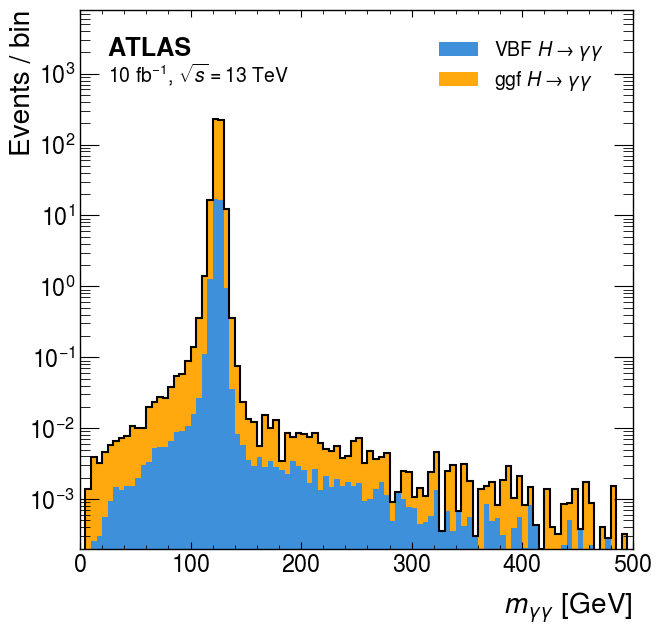

In [5]:
def stat_uc():
    # EXERCISE: Calculate the stat u/c
    err = np.zeros(100)
    return err
    
def plotStack():
    ''' Make a stacked histogram of the diphoton mass '''
    fig, ax = plt.subplots(figsize=(7,7))
    # plot histogram or Higgs processes (stacked and weighted)
    n, bins, _ = ax.hist(
        [df_vbf['diphoton_mass'],df_ggf['diphoton_mass']], 
        weights = [df_vbf['histoweight'],df_ggf['histoweight']], 
        histtype='barstacked',
        label = ['VBF $H\\rightarrow\\gamma\\gamma$','ggf $H\\rightarrow\\gamma\gamma$'],
        range=(0,500),bins=100,
    )
    # add bold outline of stack
    bin_centre = (bins[1:]+bins[:-1])/2
    ax.hist(bin_centre, range=(0,500),bins=100,weights=n[1], histtype='step',color='black',linewidth=1.5)

    # add hatched band with stat u/c
    err = stat_uc()
    ax.fill_between(bin_centre, n[1]-err, n[1]+err, step='mid',hatch="\\\\\\\\",alpha=0)
    
    # axis settings
    ax.set_yscale('log')
    ax.set_ylim(2e-4,8e3)
    ax.set_ylabel('Events / bin',labelpad=-5)
    ax.set_xlabel('$m_{\\gamma\\gamma}$ [GeV]')

    # make the legend
    ax.legend()

    # Add an ATLAS label
    hep.label.exp_label(exp='ATLAS',label='', rlabel = '10 fb$^{-1}$, $\\sqrt{s} = 13$ TeV', data=True, ax = ax, loc=4)
    fig.savefig(f'{plot_path}/stacked_myy.png')
    fig.savefig(f'{plot_path}/stacked_myy.pdf')
    plt.show()

plotStack()

Solution:

In [6]:
def stat_uc():
    sumw2 = np.histogram(df_vbf['diphoton_mass'], weights = df_vbf['histoweight']**2, range=(0,500),bins=100)[0]
    sumw2 += np.histogram(df_ggf['diphoton_mass'], weights = df_ggf['histoweight']**2, range=(0,500),bins=100)[0]
    err = np.sqrt(sumw2)
    return err

#### Plotting the signal, data and a fitted background function

Now we will use the data outside a blinded region to fit an exponential function, and plot this alongside the signal and data.

Exercise:
* Try fitting a 4th order polynomial instead of an exponential function.

Fitting exponential function...
Fitted parameters: [ 4.16735804  0.0304542  12.66839706]


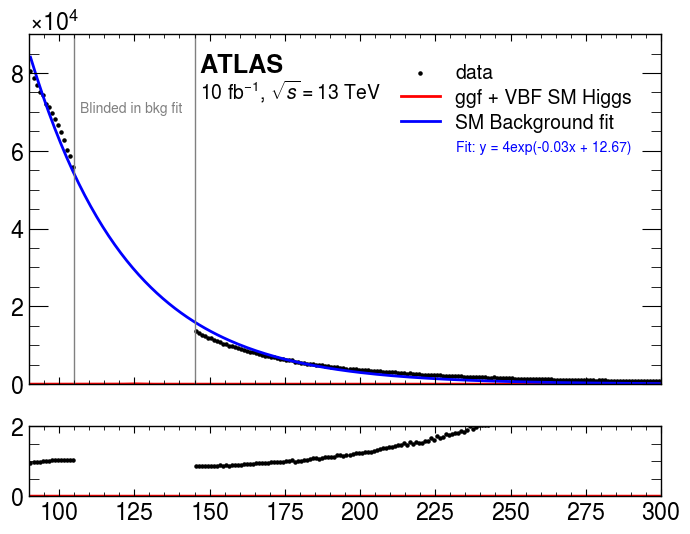

In [7]:
def exp_func(x, a, b, c):
    return a*np.exp(-b*x + c)

def plotSigBgData(blind=True):
    '''
    Plot signal and data, and fit/plot a parameterised background estimate
    '''

    fig, (ax, ax_r) = plt.subplots(2, 1, gridspec_kw = {'height_ratios':[5,1]}, sharex=True)

    n_data, bins_data = np.histogram(df_data['diphoton_mass'], range=(90,300), bins=210)
    n_sig, bins_sig = np.histogram(df_allHiggs['diphoton_mass'], range=(90,300), bins=210, weights = df_allHiggs['histoweight'])
    
    bin_centre = (bins_data[1:] + bins_data[:-1])/2
    bin_centre_sig = (bins_sig[1:] + bins_sig[:-1])/2
    
    if blind:
        # Blind between 105 and 145 GeV
        blind_region = np.logical_or(bin_centre<105, bin_centre>145)
        bin_centre = bin_centre[blind_region]
        n_data = n_data[blind_region]

    # Fit an exponential function between 90 and 300 GeV (excluding the blinded data)
    # Task: Try a 4th order polynomial instead
    print('Fitting exponential function...')
    popt, pcov = curve_fit(exp_func, bin_centre, n_data, p0 = [1,0.01,10])
    print('Fitted parameters:',popt)
    ax.text(232,60000,f'Fit: y = {round(popt[0])}exp(-{round(popt[1],2)}x + {round(popt[2],2)})',color='blue',fontsize=10)
    
    ax.scatter(bin_centre, n_data, color='black', s=5, label='data')
    ax.plot(bin_centre_sig, n_sig,color='red',label='ggf + VBF SM Higgs')
    ax.plot(bin_centre_sig, exp_func(bin_centre_sig, *popt),'b-',label='SM Background fit')

    ax.set_ylim(0,90_000)
    ax.set_xlim(90,300)

    # indicate the blinded region
    ax.axvline(x=105, ymin=0, ymax=1, color='gray',linewidth=1)
    ax.axvline(x=145, ymin=0, ymax=1, color='gray',linewidth=1)
    ax.text(107,70000,'Blinded in bkg fit',color='gray',fontsize=10)
    
    # add ratios
    ratio_data = n_data / exp_func(bin_centre,*popt)
    ratio_sig = n_sig / exp_func(bin_centre_sig,*popt)
    ax_r.scatter(bin_centre, ratio_data, color='black', s=5)
    ax_r.plot(bin_centre_sig, ratio_sig, color='red')
    ax_r.set_ylim(0,2.0)
    
    # Make dummy axes to fine-tune ATLAS badge location
    ax_dummy = ax.inset_axes([0.23,0.85,0.8,0.1])
    hep.label.exp_label(exp='ATLAS',label='', rlabel = '10 fb$^{-1}$, $\\sqrt{s} = 13$ TeV', data=True, ax = ax_dummy, loc=4)
    ax_dummy.axis('off')

    ax.legend(loc='upper right')
    
    fig.savefig(f'{plot_path}/SigDataBgFit_myy.png')
    fig.savefig(f'{plot_path}/SigDataBgFit_myy.pdf')
    plt.show()

plotSigBgData(True)